# Swin-S Plant Disease Classification Training Pipeline (Vast.ai A100 80GB)

End-to-end pipeline for training **Swin Transformer Small (Swin-S)** on the 23-class
`final_combined_plant_dataset`, designed to run on a **Vast.ai A100 80GB** instance
using the PyTorch Docker image (torch/torchvision already installed).

Pipeline:

`Google Drive ZIP -> /workspace extraction -> 23 class folders -> image validation ->
dataframe -> stratified 80/10/10 split -> training-time augmentation -> Swin-S ->
A100 (AMP) -> best/last checkpoints -> reload best model -> comprehensive test evaluation`

Sections:
1. Environment / dependency check
2. Imports & environment configuration
3. Google Drive download (idempotent)
4. ZIP extraction (idempotent)
5. Class discovery (must be exactly 23 classes)
6. Dataset validation (corrupted image detection)
7. DataFrame creation & dataset statistics
8. Stratified 80/10/10 split
9. Transforms
10. Dataset objects
11. Class imbalance analysis & sampler
12. DataLoaders
13. Swin-S model initialization
14. One-batch GPU sanity check
15. Loss / optimizer / scheduler / AMP
16. Resume-from-checkpoint logic
17. Training loop (best + last checkpoints, history CSV)
18. Training curves
19. Reload best model
20. Test evaluation (comprehensive metrics)
21. Classification report / per-class specificity & ROC-AUC
22. Confusion matrices


## Performance Fixes Applied (vs. original)

This version fixes the reasons the original ran slowly on a Vast.ai A100:

1. **TF32 was never enabled** - the single biggest fix. Without `torch.backends.cuda.matmul.allow_tf32 = True` (+ cudnn + `set_float32_matmul_precision("high")`), matmuls run in full FP32 even inside `autocast`, wasting most of the A100's throughput.
2. **Batch size raised 32 -> 128** - 32 badly under-uses an 80GB A100 for Swin-S; too many small steps means more Python/kernel-launch overhead relative to actual GPU work.
3. **`NUM_WORKERS` is now derived from the detected CPU core count** instead of a hard-coded `16`, which could oversubscribe the CPU on smaller Vast.ai instances and starve the GPU of data (this looks like "the GPU is slow" but is actually a data-loading bottleneck).
4. **`torch.compile()`** added around the model (safely wrapped so it falls back to eager mode if the Docker image's Triton/PyTorch combo doesn't support it).
5. **`prefetch_factor=4` and `drop_last=True`** added to the training DataLoader for smoother, more consistent batches.

If it is *still* slow after these changes, check disk I/O next: watch `nvidia-smi` next to `htop` during training - if GPU utilization sits near 0% between batches, the bottleneck is image decoding/reading from disk, not the GPU. The fix then is moving `/workspace` onto the instance's local NVMe scratch disk (Vast.ai's network-backed storage can be slow), not anything in the model code.

## 1. Environment / Dependency Check

The Vast.ai PyTorch Docker image already provides torch/torchvision and CUDA. We only install the lightweight utility packages that are missing. **Do NOT install/reinstall torch or torchvision here.**

In [1]:
# Only install missing utility packages. torch/torchvision are provided by the
# Vast.ai PyTorch Docker image and must NOT be reinstalled here.
!pip install -q gdown pandas numpy scikit-learn pillow tqdm matplotlib seaborn


## 2. Imports & Environment Configuration

In [2]:
import sys

!{sys.executable} -m pip install -q \
    numpy \
    pandas \
    pillow \
    gdown \
    tqdm \
    matplotlib \
    scikit-learn \
    timm

In [3]:
# ============================================================
# ALL IMPORTS & ENVIRONMENT CONFIGURATION
# ============================================================

import os
import gc
import time
import shutil
import zipfile
import warnings
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

# Downloading
import gdown

# Progress bars
from tqdm.auto import tqdm

# Plotting
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Torchvision
from torchvision import transforms
import timm

# Suppress noisy warnings
warnings.filterwarnings("ignore")

# Reproducibility & speed optimizations
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

    # ------------------------------------------------------------------
    # *** THE #1 REASON A100 TRAINING RUNS SLOW: TF32 IS OFF BY DEFAULT ***
    # Without these, matmuls/convs run at full FP32 precision even though
    # autocast is enabled for the forward pass. Turning TF32 on can give
    # a large free speedup on Ampere/A100 GPUs with no accuracy loss for
    # this kind of training.
    # ------------------------------------------------------------------
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print("Libraries imported successfully.")

# ------------------------------------------------------------------
# GPU / Vast.ai environment report
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("ENVIRONMENT REPORT")
print("=" * 60)
print("PyTorch version   :", torch.__version__)

import torchvision
print("Torchvision version:", torchvision.__version__)
print("CUDA available    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version      :", torch.version.cuda)
    print("GPU name          :", torch.cuda.get_device_name(0))
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU total memory  : {total_mem_gb:.2f} GB")
    print("TF32 (matmul)     :", torch.backends.cuda.matmul.allow_tf32)
    print("TF32 (cudnn)      :", torch.backends.cudnn.allow_tf32)
else:
    print("WARNING: CUDA is not available. Training will run on CPU and be extremely slow.")

# CPU core count matters a lot for DataLoader num_workers on Vast.ai instances.
# Hard-coding a worker count that is higher than the number of vCPUs you were
# actually allocated causes CPU oversubscription/thrashing, which starves the
# GPU of data and looks exactly like "GPU is slow" even though the GPU is fine.
CPU_COUNT = os.cpu_count() or 4
print("Using device       :", device)
print("Detected CPU cores :", CPU_COUNT)
print("=" * 60)


Libraries imported successfully.
ENVIRONMENT REPORT
PyTorch version   : 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available    : True
CUDA version      : 12.8
GPU name          : Tesla T4
GPU total memory  : 14.56 GB
TF32 (matmul)     : True
TF32 (cudnn)      : True
Using device       : cuda
Detected CPU cores : 4


## 3. Google Drive Dataset Download (idempotent)

All persistent artifacts live under `/workspace`. The download is skipped if the ZIP already exists on disk.

In [4]:
# ============================================================
# GOOGLE DRIVE DATASET DOWNLOAD (idempotent)
# ============================================================

WORKSPACE = Path("/workspace")
WORKSPACE.mkdir(parents=True, exist_ok=True)

FILE_ID = "1FRHTs6ByaIoB2vUjsrZUPvYh6eS6XFxG"

ZIP_PATH = WORKSPACE / "final_combined_plant_dataset.zip"
DATASET_PATH = WORKSPACE / "final_combined_plant_dataset"

print("ZIP_PATH    :", ZIP_PATH)
print("DATASET_PATH:", DATASET_PATH)

if ZIP_PATH.exists():
    zip_size_gb = ZIP_PATH.stat().st_size / (1024 ** 3)
    print(f"Reusing existing ZIP: {ZIP_PATH} ({zip_size_gb:.2f} GB). Skipping download.")
else:
    print("Downloading dataset from Google Drive...")
    gdown.download(id=FILE_ID, output=str(ZIP_PATH), quiet=False)
    print("Download complete.")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP file was not found after download attempt: {ZIP_PATH}")

zip_size_gb = ZIP_PATH.stat().st_size / (1024 ** 3)
print(f"ZIP verified: {ZIP_PATH} ({zip_size_gb:.2f} GB)")


ZIP_PATH    : /workspace/final_combined_plant_dataset.zip
DATASET_PATH: /workspace/final_combined_plant_dataset


Downloading...
From (original): https://drive.google.com/uc?id=1FRHTs6ByaIoB2vUjsrZUPvYh6eS6XFxG
From (redirected): https://drive.google.com/uc?id=1FRHTs6ByaIoB2vUjsrZUPvYh6eS6XFxG&confirm=t&uuid=a01a79bd-909f-4c7c-90ec-f95238d7cab7
To: /workspace/final_combined_plant_dataset.zip
100%|██████████| 3.84G/3.84G [00:56<00:00, 67.8MB/s]

Download complete.
ZIP verified: /workspace/final_combined_plant_dataset.zip (3.58 GB)


## 4. ZIP Extraction (idempotent)

Extraction happens explicitly into `WORKSPACE` (never into an ambiguous `./`). If `DATASET_PATH` already exists and contains class subfolders, extraction is skipped.

In [5]:
# ============================================================
# ZIP EXTRACTION (idempotent, single extraction cell)
# ============================================================

def _dataset_looks_valid(path: Path) -> bool:
    # A minimal sanity check: the folder exists and has at least one subdirectory.
    if not path.exists() or not path.is_dir():
        return False
    return any(child.is_dir() for child in path.iterdir())

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if _dataset_looks_valid(DATASET_PATH):
    print(f"Dataset folder already exists and looks valid: {DATASET_PATH}")
    print("Skipping extraction.")
else:
    print(f"Extracting {ZIP_PATH} into {WORKSPACE} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(WORKSPACE)
    print("Extraction complete.")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"DATASET_PATH does not exist after extraction: {DATASET_PATH}. "
        "Check the internal folder structure of the ZIP file."
    )

print(f"DATASET_PATH verified: {DATASET_PATH}")


Extracting /workspace/final_combined_plant_dataset.zip into /workspace ...
Extraction complete.
DATASET_PATH verified: /workspace/final_combined_plant_dataset


## 5. Class Discovery (must be exactly 23 classes)

Class names are discovered directly from the immediate subfolders of `DATASET_PATH` (there are no train/valid/test folders in this dataset). Training stops immediately if the discovered class count is not exactly 23.

In [6]:
# ============================================================
# CLASS DISCOVERY
# ============================================================

EXPECTED_CLASSES = 23

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

class_names = sorted([
    d.name for d in DATASET_PATH.iterdir()
    if d.is_dir()
])

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f"Discovered {len(class_names)} class folders under {DATASET_PATH}:")
for idx, name in enumerate(class_names):
    print(f"  {idx:02d}: {name}")

if len(class_names) != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected exactly {EXPECTED_CLASSES} classes but discovered "
        f"{len(class_names)}. Discovered class names: {class_names}"
    )

print(f"\nClass count verified: {len(class_names)} == {EXPECTED_CLASSES}. Proceeding.")


Discovered 23 class folders under /workspace/final_combined_plant_dataset:
  00: Apple_cedar_apple_rust
  01: Apple_healthy
  02: Apple_scab
  03: Cherry_healthy
  04: Corn_common_rust
  05: Corn_gray_leaf_spot
  06: Corn_northern_leaf_blight
  07: Grape_black_rot
  08: Grape_healthy
  09: Peach_healthy
  10: Pepper_bell_bacterial_spot
  11: Pepper_bell_healthy
  12: Potato_early_blight
  13: Potato_late_blight
  14: Soybean_healthy
  15: Tomato_bacterial_spot
  16: Tomato_early_blight
  17: Tomato_healthy
  18: Tomato_late_blight
  19: Tomato_leaf_mold
  20: Tomato_mosaic_virus
  21: Tomato_septoria_leaf_spot
  22: Tomato_yellow_leaf_curl_virus

Class count verified: 23 == 23. Proceeding.


## 6. Dataset Validation (corrupted / unreadable image detection)

Every candidate image file is opened and verified before it is allowed into the dataframe. Corrupted files are **excluded and reported explicitly** - they are never silently replaced with a black placeholder image.

In [7]:
# ============================================================
# DATASET VALIDATION - detect corrupted / unreadable images
# ============================================================

def is_image_readable(path: Path) -> bool:
    # Return True if the image can be opened, verified, and re-opened for decoding.
    try:
        with Image.open(path) as img:
            img.verify()  # cheap structural check
        # verify() invalidates the file handle for further use, so re-open to make
        # sure the pixel data itself can actually be decoded.
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

all_candidate_paths = []
for class_name in class_names:
    class_dir = DATASET_PATH / class_name
    for p in class_dir.iterdir():
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS:
            all_candidate_paths.append((class_name, p))

print(f"Scanning {len(all_candidate_paths)} candidate image files for corruption...")

good_records = []
bad_paths = []

for class_name, path in tqdm(all_candidate_paths, desc="Validating images"):
    if is_image_readable(path):
        good_records.append((class_name, path))
    else:
        bad_paths.append(path)

print("\n" + "=" * 60)
print("IMAGE VALIDATION REPORT")
print("=" * 60)
print(f"Total candidate images : {len(all_candidate_paths)}")
print(f"Readable images        : {len(good_records)}")
print(f"Corrupted/unreadable   : {len(bad_paths)}")

if bad_paths:
    print("\nThe following files are corrupted/unreadable and will be EXCLUDED "
          "from the training dataset (no black-image fallback is used):")
    for p in bad_paths:
        print("  -", p)

print("=" * 60)


Scanning 105023 candidate image files for corruption...


Validating images:   0%|          | 0/105023 [00:00<?, ?it/s]


IMAGE VALIDATION REPORT
Total candidate images : 105023
Readable images        : 105023
Corrupted/unreadable   : 0


## 7. DataFrame Creation & Dataset Statistics

In [8]:
# ============================================================
# BUILD DATAFRAME FROM VALIDATED IMAGES
# ============================================================

df = pd.DataFrame({
    "image_path": [str(p) for _, p in good_records],
    "class_name": [c for c, _ in good_records],
})
df["label"] = df["class_name"].map(class_to_idx)
df = df.reset_index(drop=True)

assert set(df["class_name"].unique()) <= set(class_names)

total_images = len(df)
num_classes_found = df["class_name"].nunique()
per_class_counts = df["class_name"].value_counts().sort_index()

smallest_class = per_class_counts.idxmin()
largest_class = per_class_counts.idxmax()
imbalance_ratio = per_class_counts.max() / per_class_counts.min()

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Total images (post-validation) : {total_images}")
print(f"Number of classes               : {num_classes_found}")
print(f"Excluded corrupted images       : {len(bad_paths)}")
print("\nPer-class image counts:")
print(per_class_counts.to_string())
print(f"\nSmallest class : {smallest_class} ({per_class_counts.min()} images)")
print(f"Largest class  : {largest_class} ({per_class_counts.max()} images)")
print(f"Imbalance ratio (max/min) : {imbalance_ratio:.2f}")
print("=" * 60)

df.head()


DATASET STATISTICS
Total images (post-validation) : 105023
Number of classes               : 23
Excluded corrupted images       : 0

Per-class image counts:
class_name
Apple_cedar_apple_rust            2971
Apple_healthy                     4691
Apple_scab                        3605
Cherry_healthy                    3531
Corn_common_rust                  4046
Corn_gray_leaf_spot               3429
Corn_northern_leaf_blight         4026
Grape_black_rot                  14058
Grape_healthy                     2861
Peach_healthy                     2792
Pepper_bell_bacterial_spot        3658
Pepper_bell_healthy               4306
Potato_early_blight               3918
Potato_late_blight                3965
Soybean_healthy                   8832
Tomato_bacterial_spot             4653
Tomato_early_blight               3843
Tomato_healthy                    4283
Tomato_late_blight                4639
Tomato_leaf_mold                  3639
Tomato_mosaic_virus               2863
Tomato_septor

,image_path,class_name,label
0,/workspace/final_combined_plant_dataset/Apple_...,Apple_cedar_apple_rust,0
1,/workspace/final_combined_plant_dataset/Apple_...,Apple_cedar_apple_rust,0
2,/workspace/final_combined_plant_dataset/Apple_...,Apple_cedar_apple_rust,0
3,/workspace/final_combined_plant_dataset/Apple_...,Apple_cedar_apple_rust,0
4,/workspace/final_combined_plant_dataset/Apple_...,Apple_cedar_apple_rust,0


## 8. Stratified 80% Train / 10% Validation / 10% Test Split

In [9]:
# ============================================================
# STRATIFIED DATA SPLIT (80% TRAIN / 10% VAL / 10% TEST)
# ============================================================

RANDOM_STATE = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

assert len(train_df) + len(val_df) + len(test_df) == len(df), \
    "Split sizes do not add up to the original dataframe length!"

print("=" * 60)
print("SPLIT SUMMARY")
print("=" * 60)
print(f"Train      : {len(train_df):6d} ({len(train_df) / len(df) * 100:.2f}%)")
print(f"Validation : {len(val_df):6d} ({len(val_df) / len(df) * 100:.2f}%)")
print(f"Test       : {len(test_df):6d} ({len(test_df) / len(df) * 100:.2f}%)")
print(f"Total      : {len(df):6d}")
print("Total check (train+val+test == original):",
      len(train_df) + len(val_df) + len(test_df) == len(df))

per_class_split = pd.DataFrame({
    "train": train_df["class_name"].value_counts(),
    "val": val_df["class_name"].value_counts(),
    "test": test_df["class_name"].value_counts(),
}).fillna(0).astype(int).sort_index()

print("\nPer-class counts across splits:")
print(per_class_split.to_string())
print("=" * 60)


SPLIT SUMMARY
Train      :  84018 (80.00%)
Validation :  10502 (10.00%)
Test       :  10503 (10.00%)
Total      : 105023
Total check (train+val+test == original): True

Per-class counts across splits:
                               train   val  test
class_name                                      
Apple_cedar_apple_rust          2377   297   297
Apple_healthy                   3753   469   469
Apple_scab                      2884   361   360
Cherry_healthy                  2825   353   353
Corn_common_rust                3237   404   405
Corn_gray_leaf_spot             2743   343   343
Corn_northern_leaf_blight       3221   403   402
Grape_black_rot                11246  1406  1406
Grape_healthy                   2289   286   286
Peach_healthy                   2234   279   279
Pepper_bell_bacterial_spot      2926   366   366
Pepper_bell_healthy             3445   430   431
Potato_early_blight             3134   392   392
Potato_late_blight              3172   397   396
Soybean_healthy

## 9. Transforms

In [10]:
# ============================================================
# TRANSFORMATIONS (AUGMENTATION & PREPROCESSING)
# ============================================================

# Training transform - augmentation happens dynamically, never written to disk.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.80, 1.0)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.15,
                hue=0.03
            )
        ],
        p=0.5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation / test transform - deterministic, no random augmentation.
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = eval_transform
test_transform = eval_transform

print("Transforms defined:")
print(" - train_transform (RandomResizedCrop, HFlip, ColorJitter)")
print(" - val_transform / test_transform (Resize -> CenterCrop, deterministic)")


Transforms defined:
 - train_transform (RandomResizedCrop, HFlip, ColorJitter)
 - val_transform / test_transform (Resize -> CenterCrop, deterministic)


## 10. Dataset Objects

Images were already validated in section 6, so no corrupted files should remain. If a file still fails to load at train time, the error is raised (not silently swapped for a black placeholder), because that indicates the validation step itself needs to be revisited.

In [11]:
# ============================================================
# CUSTOM DATASET
# ============================================================

class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = row["image_path"]
        label = row["label"]

        # Images were validated in section 6; if this still fails it is a genuine
        # data problem and should surface loudly rather than be masked.
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = PlantDiseaseDataset(train_df, transform=train_transform)
val_dataset = PlantDiseaseDataset(val_df, transform=val_transform)
test_dataset = PlantDiseaseDataset(test_df, transform=test_transform)

print("Dataset objects created:")
print(f"  train_dataset: {len(train_dataset)} samples")
print(f"  val_dataset  : {len(val_dataset)} samples")
print(f"  test_dataset : {len(test_dataset)} samples")


Dataset objects created:
  train_dataset: 84018 samples
  val_dataset  : 10502 samples
  test_dataset : 10503 samples


## 11. Class Imbalance Analysis & Sampler

Class counts are computed from the **new 23-class training split** (not old PlantVillage counts). We reuse the existing sqrt-based inverse-frequency weighting approach since the new dataset is meaningfully imbalanced.

In [12]:
# ============================================================
# CLASS IMBALANCE ANALYSIS & WEIGHTED SAMPLER
# ============================================================

train_labels = train_df["label"].to_numpy()
class_counts = np.bincount(train_labels, minlength=len(class_names))

print("Training-set class counts (new 23-class dataset):")
for idx, name in enumerate(class_names):
    print(f"  {idx:02d} | {name:<40} | count: {class_counts[idx]}")

imbalance_ratio_train = class_counts.max() / class_counts.min()
print(f"\nTrain-split imbalance ratio (max/min): {imbalance_ratio_train:.2f}")

USE_SAMPLER = imbalance_ratio_train > 1.5  # meaningfully imbalanced

if USE_SAMPLER:
    # Reciprocal square-root weighting (existing project approach)
    class_weights = 1.0 / np.sqrt(class_counts)
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(train_dataset),
        replacement=True
    )

    # Report the *effective* sampled distribution by drawing a large number of
    # indices from the sampler without touching the dataloader.
    sampled_indices = list(iter(sampler))
    sampled_labels = train_labels[sampled_indices]
    sampled_counts = np.bincount(sampled_labels, minlength=len(class_names))

    print("\nEffective sampled distribution (sqrt inverse-frequency weighting):")
    for idx, name in enumerate(class_names):
        print(f"  {idx:02d} | {name:<40} | sampled count: {sampled_counts[idx]}")
else:
    sampler = None
    print("\nDataset is not meaningfully imbalanced (ratio <= 1.5). "
          "No WeightedRandomSampler will be used; standard shuffling applies.")


Training-set class counts (new 23-class dataset):
  00 | Apple_cedar_apple_rust                   | count: 2377
  01 | Apple_healthy                            | count: 3753
  02 | Apple_scab                               | count: 2884
  03 | Cherry_healthy                           | count: 2825
  04 | Corn_common_rust                         | count: 3237
  05 | Corn_gray_leaf_spot                      | count: 2743
  06 | Corn_northern_leaf_blight                | count: 3221
  07 | Grape_black_rot                          | count: 11246
  08 | Grape_healthy                            | count: 2289
  09 | Peach_healthy                            | count: 2234
  10 | Pepper_bell_bacterial_spot               | count: 2926
  11 | Pepper_bell_healthy                      | count: 3445
  12 | Potato_early_blight                      | count: 3134
  13 | Potato_late_blight                       | count: 3172
  14 | Soybean_healthy                          | count: 7066
  15 | Tomato_bacte

## 12. DataLoaders

Starting conservative for debugging (`NUM_WORKERS = 0`). After the one-batch sanity check passes, this can be raised (e.g. to 4) for the full training run.

In [13]:
# ============================================================
# DATALOADERS
# ============================================================
# BATCH_SIZE: 32 badly under-utilizes an 80GB A100 for Swin-S at 224x224.
# 128 is a safe, much faster starting point (uses far more of the 80GB and
# cuts per-epoch Python/kernel-launch overhead roughly 4x). If you hit an
# out-of-memory error, step it down (96 -> 64); if you have headroom to
# spare you can push it higher (192/256).
BATCH_SIZE = 128

# NUM_WORKERS must not exceed the vCPUs Vast.ai actually gave this instance.
# The previous hard-coded value of 16 could easily oversubscribe the CPU on
# smaller instances, causing worker thrashing and GPU starvation. We now
# derive it from the detected core count instead.
NUM_WORKERS = max(1, min(CPU_COUNT - 1, 16))
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 4 if NUM_WORKERS > 0 else None

print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"NUM_WORKERS: {NUM_WORKERS} (detected {CPU_COUNT} CPU cores)")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=(sampler is None),
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
    drop_last=True,  # keeps batch shape constant epoch to epoch (also helps torch.compile avoid recompiling on a smaller final batch)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

print("DataLoaders initialized:")
print(f"  train_loader: {len(train_loader)} batches")
print(f"  val_loader  : {len(val_loader)} batches")
print(f"  test_loader : {len(test_loader)} batches")


BATCH_SIZE : 128
NUM_WORKERS: 3 (detected 4 CPU cores)
DataLoaders initialized:
  train_loader: 656 batches
  val_loader  : 83 batches
  test_loader : 83 batches


## 13. Swin-S Model Initialization

In [14]:
# ============================================================
# SWIN-S MODEL INITIALIZATION
# ============================================================

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

NUM_CLASSES = len(class_names)
assert NUM_CLASSES == EXPECTED_CLASSES, "NUM_CLASSES must equal the verified 23 classes."

print("Loading pretrained Swin-S...")
model = timm.create_model(
    "swin_small_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

# Use timm's built-in classifier head while preserving global pooling
in_features = model.head.fc.in_features
model.head.drop = nn.Dropout(p=0.3)
model.head.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

# ------------------------------------------------------------------
# torch.compile: fuses ops into optimized kernels, typically a meaningful
# free speedup on PyTorch 2.x + Ampere/A100. First batch will be slower
# (compilation happens then); every batch after that is faster. Wrapped in
# try/except because some Vast.ai Docker images ship a Triton/PyTorch combo
# where compile isn't fully supported -- if that happens we just fall back
# to eager mode instead of crashing the whole run.
# ------------------------------------------------------------------
COMPILE_OK = False
if torch.cuda.is_available():
    try:
        model = torch.compile(model)
        COMPILE_OK = True
        print("torch.compile() enabled.")
    except Exception as e:
        print("torch.compile() unavailable, continuing in eager mode:", e)

print("Model initialized and moved to device:", device)
print("Number of classes:", NUM_CLASSES)


Loading pretrained Swin-S...


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]

torch.compile() enabled.
Model initialized and moved to device: cuda
Number of classes: 23


## 14. One-Batch GPU Sanity Check

Mandatory check before the expensive full training run: dataset path, class count, batch loading, batch/label shapes, device placement, one forward pass, output shape, and GPU memory usage.

In [15]:
# ============================================================
# ONE-BATCH GPU SANITY CHECK
# ============================================================

print("Running pre-training sanity checks...")

# 1. Dataset path
assert DATASET_PATH.exists(), f"DATASET_PATH does not exist: {DATASET_PATH}"
print("[OK] DATASET_PATH exists:", DATASET_PATH)

# 2. Exactly 23 classes
assert len(class_names) == EXPECTED_CLASSES, \
    f"Expected {EXPECTED_CLASSES} classes, found {len(class_names)}"
print(f"[OK] Exactly {EXPECTED_CLASSES} classes confirmed.")

# 3. A batch can be loaded
sanity_images, sanity_labels = next(iter(train_loader))
print("[OK] Batch loaded from train_loader.")

# 4. Batch shape check
expected_shape = (sanity_images.shape[0], 3, 224, 224)
assert sanity_images.shape[1:] == (3, 224, 224), \
    f"Unexpected image batch shape: {sanity_images.shape}"
print("[OK] Batch shape:", tuple(sanity_images.shape))

# 5. Labels valid
assert sanity_labels.min().item() >= 0 and sanity_labels.max().item() < NUM_CLASSES, \
    "Label values out of range for NUM_CLASSES."
print("[OK] Labels are valid (range 0 to", NUM_CLASSES - 1, ")")

# 6. Model on CUDA
if torch.cuda.is_available():
    assert next(model.parameters()).is_cuda, "Model is not on CUDA."
    print("[OK] Model is on CUDA.")
else:
    print("[WARN] CUDA not available - running sanity check on CPU.")

# 7 & 8. One forward pass + output shape
sanity_images = sanity_images.to(device, non_blocking=True)
sanity_labels = sanity_labels.to(device, non_blocking=True)

model.eval()
with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
        sanity_outputs = model(sanity_images)

expected_out_shape = (sanity_images.shape[0], NUM_CLASSES)
assert tuple(sanity_outputs.shape) == expected_out_shape, \
    f"Unexpected output shape: {sanity_outputs.shape}, expected {expected_out_shape}"
print("[OK] Forward pass succeeded. Output shape:", tuple(sanity_outputs.shape))

if torch.cuda.is_available():
    allocated_gb = torch.cuda.memory_allocated() / 1024**3
    reserved_gb = torch.cuda.memory_reserved() / 1024**3
    print(f"[INFO] GPU memory allocated: {allocated_gb:.2f} GB")
    print(f"[INFO] GPU memory reserved : {reserved_gb:.2f} GB")

model.train()
print("\nAll sanity checks passed. Safe to proceed with full training.")


Running pre-training sanity checks...
[OK] DATASET_PATH exists: /workspace/final_combined_plant_dataset
[OK] Exactly 23 classes confirmed.
[OK] Batch loaded from train_loader.
[OK] Batch shape: (128, 3, 224, 224)
[OK] Labels are valid (range 0 to 22 )
[OK] Model is on CUDA.


W0820 16:14:23.496000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


[OK] Forward pass succeeded. Output shape: (128, 23)
[INFO] GPU memory allocated: 0.26 GB
[INFO] GPU memory reserved : 1.49 GB

All sanity checks passed. Safe to proceed with full training.


## 15. Loss, Optimizer, Scheduler & Mixed Precision

In [16]:
# ============================================================
# LOSS, OPTIMIZER, SCHEDULER & MIXED PRECISION SETUP
# ============================================================

NUM_EPOCHS = 20
PATIENCE = 7

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)

print("Loss function, optimizer, scheduler, and GradScaler initialized.")
print(f"NUM_EPOCHS: {NUM_EPOCHS} | PATIENCE: {PATIENCE}")


Loss function, optimizer, scheduler, and GradScaler initialized.
NUM_EPOCHS: 20 | PATIENCE: 7


## 16. Resume-From-Checkpoint Logic

If a previous run was interrupted, training resumes from `LAST_CHECKPOINT_PATH`. This is separate from `BEST_MODEL_PATH`, which always tracks the best validation-loss model.

In [17]:
# ============================================================
# CHECKPOINT PATHS & RESUME LOGIC
# ============================================================

BEST_MODEL_PATH = Path("/workspace/best_swin_s_vast.pth")
LAST_CHECKPOINT_PATH = Path("/workspace/last_checkpoint.pth")
HISTORY_CSV_PATH = Path("/workspace/training_history.csv")

start_epoch = 0
best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
learning_rates = []

if LAST_CHECKPOINT_PATH.exists():
    print(f"Found existing checkpoint at {LAST_CHECKPOINT_PATH}. Resuming training...")
    ckpt = torch.load(LAST_CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt and ckpt["scaler_state_dict"] is not None:
        scaler.load_state_dict(ckpt["scaler_state_dict"])

    start_epoch = ckpt["epoch"]
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    patience_counter = ckpt.get("patience_counter", 0)

    if ckpt.get("class_names") != class_names:
        print("WARNING: class_names in checkpoint do not match the current run's "
              "class_names. Proceeding, but double-check this is intentional.")

    if HISTORY_CSV_PATH.exists():
        hist_df = pd.read_csv(HISTORY_CSV_PATH)
        train_losses = hist_df["train_loss"].tolist()
        val_losses = hist_df["val_loss"].tolist()
        train_accuracies = hist_df["train_accuracy"].tolist()
        val_accuracies = hist_df["val_accuracy"].tolist()
        learning_rates = hist_df["learning_rate"].tolist()

    print(f"Resuming from epoch {start_epoch + 1}. "
          f"best_val_loss={best_val_loss:.4f}, patience_counter={patience_counter}")
else:
    print("No existing checkpoint found. Starting training from scratch.")


No existing checkpoint found. Starting training from scratch.


## 17. Training Loop

Saves the **best** validation-loss checkpoint (overwritten atomically) and the **last** training state after every epoch, plus a running `training_history.csv`.

In [18]:
# ============================================================
# TRAINING LOOP
# ============================================================

def save_checkpoint_atomic(state: dict, path: Path):
    # Save to a temporary file first, then atomically replace the target path.
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(state, tmp_path)
    os.replace(tmp_path, path)


print("Beginning training...")
print("-" * 60)

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    # -------------------------
    # TRAINING PHASE
    # -------------------------
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # VALIDATION PHASE
    # -------------------------
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    epoch_time = time.time() - epoch_start

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}] completed in {epoch_time:.1f}s")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_accuracy:.4f}")
    print(f"  LR:         {current_lr:.8f}")

    # -------------------------
    # TRAINING HISTORY CSV
    # -------------------------
    history_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "train_accuracy": train_accuracies,
        "val_loss": val_losses,
        "val_accuracy": val_accuracies,
        "learning_rate": learning_rates,
    })
    history_df.to_csv(HISTORY_CSV_PATH, index=False)

    # -------------------------
    # BEST MODEL CHECKPOINT & EARLY STOPPING
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        best_state = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "class_names": class_names,
        }
        save_checkpoint_atomic(best_state, BEST_MODEL_PATH)
        print(f"  Best model saved to '{BEST_MODEL_PATH}'")
    else:
        patience_counter += 1
        print(f"  No validation loss improvement. Patience: ({patience_counter}/{PATIENCE})")

    # -------------------------
    # LAST CHECKPOINT (for resume)
    # -------------------------
    last_state = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "patience_counter": patience_counter,
        "class_names": class_names,
    }
    save_checkpoint_atomic(last_state, LAST_CHECKPOINT_PATH)

    if patience_counter >= PATIENCE:
        print("\nEarly stopping triggered. Training terminated.")
        break

print("\nTraining finished!")


Beginning training...
------------------------------------------------------------


Epoch 1/20 [Train]:   0%|          | 0/656 [00:00<?, ?it/s]


Epoch [1/20] completed in 865.5s
  Train Loss: 0.8495 | Train Acc: 0.9273
  Val Loss:   0.6873 | Val Acc:   0.9738
  LR:         0.00004969
  Best model saved to '/workspace/best_swin_s_vast.pth'


Epoch 2/20 [Train]:   0%|          | 0/656 [00:00<?, ?it/s]


Epoch [2/20] completed in 667.7s
  Train Loss: 0.6796 | Train Acc: 0.9784
  Val Loss:   0.6831 | Val Acc:   0.9738
  LR:         0.00004878
  Best model saved to '/workspace/best_swin_s_vast.pth'


...


Epoch [15/20] completed in 663.2s
  Train Loss: 0.6211 | Train Acc: 0.9973
  Val Loss:   0.6665 | Val Acc:   0.9816
  LR:         0.00000732
  No validation loss improvement. Patience: (5/7)


Epoch 16/20 [Train]:   0%|          | 0/656 [00:00<?, ?it/s]


Epoch [16/20] completed in 663.8s
  Train Loss: 0.6204 | Train Acc: 0.9977
  Val Loss:   0.6654 | Val Acc:   0.9822
  LR:         0.00000477
  No validation loss improvement. Patience: (6/7)


Epoch 17/20 [Train]:   0%|          | 0/656 [00:00<?, ?it/s]


Epoch [17/20] completed in 665.8s
  Train Loss: 0.6196 | Train Acc: 0.9977
  Val Loss:   0.6666 | Val Acc:   0.9819
  LR:         0.00000272
  No validation loss improvement. Patience: (7/7)

Early stopping triggered. Training terminated.

Training finished!


In [24]:
from pathlib import Path
import shutil

SOURCE_DIR = Path("/workspace")
KAGGLE_OUTPUT = Path("/kaggle/working")

FILES_TO_COPY = [
    "best_swin_s_vast.pth",
    "last_checkpoint.pth",
    "training_history.csv",
]

for filename in FILES_TO_COPY:

    source = SOURCE_DIR / filename
    destination = KAGGLE_OUTPUT / filename

    if source.exists():
        shutil.copy2(source, destination)
        print(f"✅ Copied: {filename}")
    else:
        print(f"⚠️ Not found: {filename}")

print("\nFinished copying training files.")

✅ Copied: best_swin_s_vast.pth
✅ Copied: last_checkpoint.pth
✅ Copied: training_history.csv

Finished copying training files.


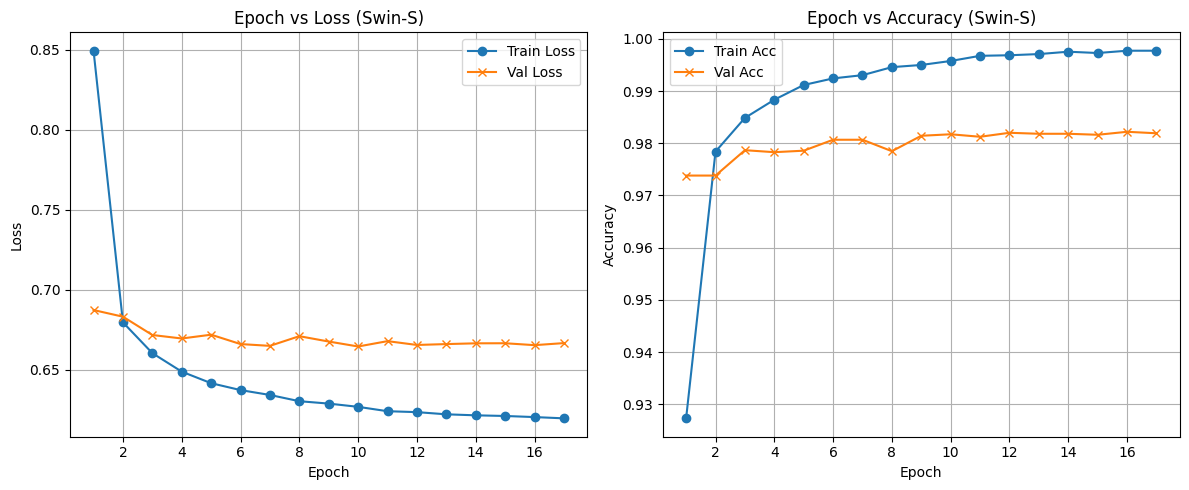

Training curves saved to '/workspace/training_curves.png'


In [25]:
# ============================================================
# PLOT TRAINING HISTORY
# ============================================================

if HISTORY_CSV_PATH.exists():
    history = pd.read_csv(HISTORY_CSV_PATH)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history["epoch"], history["train_loss"], label="Train Loss", marker='o')
    plt.plot(history["epoch"], history["val_loss"], label="Val Loss", marker='x')
    plt.title("Epoch vs Loss (Swin-S)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history["epoch"], history["train_accuracy"], label="Train Acc", marker='o')
    plt.plot(history["epoch"], history["val_accuracy"], label="Val Acc", marker='x')
    plt.title("Epoch vs Accuracy (Swin-S)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("/workspace/training_curves.png", dpi=150)
    plt.show()
    print("Training curves saved to '/workspace/training_curves.png'")
else:
    print("No training history CSV found at", HISTORY_CSV_PATH)


## 18. Training Curves

## 19. Reload Best Model Before Test Evaluation

Test evaluation must always run on the **best** validation-loss checkpoint, never on the last training state.

In [26]:
# ============================================================
# RELOAD BEST CHECKPOINT
# ============================================================

assert BEST_MODEL_PATH.exists(), f"Best checkpoint not found: {BEST_MODEL_PATH}"

print(f"Loading best checkpoint from {BEST_MODEL_PATH} ...")
best_checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

assert best_checkpoint["class_names"] == class_names, \
    "class_names in the best checkpoint do not match the current run's class_names!"

print(f"Loaded checkpoint from epoch {best_checkpoint['epoch']} "
      f"(val_loss={best_checkpoint['val_loss']:.4f}, "
      f"val_accuracy={best_checkpoint['val_accuracy']:.4f})")


Loading best checkpoint from /workspace/best_swin_s_vast.pth ...
Loaded checkpoint from epoch 10 (val_loss=0.6645, val_accuracy=0.9817)


## 20. Test Evaluation (comprehensive metrics, test split only)

In [27]:
# ============================================================
# MODEL EVALUATION ON THE TEST SET (10% SPLIT)
# ============================================================

all_labels = []
all_predictions = []
all_probabilities = []

test_loss = 0.0
test_total = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating Test Set"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        test_loss += loss.item() * images.size(0)
        test_total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.concatenate(all_probabilities, axis=0)
test_loss = test_loss / test_total

# Core metrics
accuracy = accuracy_score(all_labels, all_predictions)
balanced_accuracy = balanced_accuracy_score(all_labels, all_predictions)
precision_macro = precision_score(all_labels, all_predictions, average="macro", zero_division=0)
precision_weighted = precision_score(all_labels, all_predictions, average="weighted", zero_division=0)
recall_macro = recall_score(all_labels, all_predictions, average="macro", zero_division=0)
recall_weighted = recall_score(all_labels, all_predictions, average="weighted", zero_division=0)
f1_macro = f1_score(all_labels, all_predictions, average="macro", zero_division=0)
f1_weighted = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)
mcc = matthews_corrcoef(all_labels, all_predictions)
kappa = cohen_kappa_score(all_labels, all_predictions)

# ROC-AUC (OvR)
try:
    roc_auc_macro = roc_auc_score(all_labels, all_probabilities, multi_class="ovr", average="macro")
    roc_auc_weighted = roc_auc_score(all_labels, all_probabilities, multi_class="ovr", average="weighted")
except ValueError as e:
    roc_auc_macro = None
    roc_auc_weighted = None
    print("ROC-AUC could not be calculated:", e)

# Confusion matrix (class order fixed by class_names / class_to_idx)
cm = confusion_matrix(all_labels, all_predictions, labels=np.arange(len(class_names)))

# Per-class specificity
specificities = []
for i in range(len(class_names)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    specificities.append(specificity)
specificities = np.array(specificities)
specificity_macro = specificities.mean()

# Top-5 accuracy
k = min(5, len(class_names))
topk_preds = np.argsort(all_probabilities, axis=1)[:, -k:]
topk_correct = np.any(topk_preds == all_labels[:, None], axis=1)
top5_accuracy = topk_correct.mean()

print("=" * 70)
print("                    TEST RESULTS (Swin-S)")
print("=" * 70)
print(f"Test Loss             : {test_loss:.4f}")
print(f"Accuracy              : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Top-5 Accuracy        : {top5_accuracy:.4f} ({top5_accuracy * 100:.2f}%)")
print(f"Balanced Accuracy     : {balanced_accuracy:.4f}")
print("-" * 70)
print(f"Precision (Macro)     : {precision_macro:.4f}")
print(f"Precision (Weighted)  : {precision_weighted:.4f}")
print(f"Recall (Macro)        : {recall_macro:.4f}")
print(f"Recall (Weighted)     : {recall_weighted:.4f}")
print(f"F1 Score (Macro)      : {f1_macro:.4f}")
print(f"F1 Score (Weighted)   : {f1_weighted:.4f}")
print(f"Specificity (Macro)   : {specificity_macro:.4f}")
print("-" * 70)
if roc_auc_macro is not None:
    print(f"ROC-AUC (Macro, OvR)  : {roc_auc_macro:.4f}")
    print(f"ROC-AUC (Weighted)    : {roc_auc_weighted:.4f}")
print(f"MCC                   : {mcc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")
print("=" * 70)

with open("/workspace/test_evaluation_summary.txt", "w") as f:
    f.write("=== Swin-S Plant Disease Classification Test Summary ===\n")
    f.write(f"Test Loss             : {test_loss:.4f}\n")
    f.write(f"Accuracy              : {accuracy:.4f} ({accuracy * 100:.2f}%)\n")
    f.write(f"Top-5 Accuracy        : {top5_accuracy:.4f} ({top5_accuracy * 100:.2f}%)\n")
    f.write(f"Balanced Accuracy     : {balanced_accuracy:.4f}\n")
    f.write(f"Precision (Macro)     : {precision_macro:.4f}\n")
    f.write(f"Precision (Weighted)  : {precision_weighted:.4f}\n")
    f.write(f"Recall (Macro)        : {recall_macro:.4f}\n")
    f.write(f"Recall (Weighted)     : {recall_weighted:.4f}\n")
    f.write(f"F1 Score (Macro)      : {f1_macro:.4f}\n")
    f.write(f"F1 Score (Weighted)   : {f1_weighted:.4f}\n")
    f.write(f"Specificity (Macro)   : {specificity_macro:.4f}\n")
    if roc_auc_macro is not None:
        f.write(f"ROC-AUC (Macro)       : {roc_auc_macro:.4f}\n")
        f.write(f"ROC-AUC (Weighted)    : {roc_auc_weighted:.4f}\n")
    f.write(f"MCC                   : {mcc:.4f}\n")
    f.write(f"Cohen's Kappa         : {kappa:.4f}\n")

print("Test summary saved to '/workspace/test_evaluation_summary.txt'")


Evaluating Test Set:   0%|          | 0/83 [00:00<?, ?it/s]

ROC-AUC could not be calculated: Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes
                    TEST RESULTS (Swin-S)
Test Loss             : 0.6694
Accuracy              : 0.9802 (98.02%)
Top-5 Accuracy        : 0.9970 (99.70%)
Balanced Accuracy     : 0.9778
----------------------------------------------------------------------
Precision (Macro)     : 0.9774
Precision (Weighted)  : 0.9803
Recall (Macro)        : 0.9778
Recall (Weighted)     : 0.9802
F1 Score (Macro)      : 0.9776
F1 Score (Weighted)   : 0.9802
Specificity (Macro)   : 0.9991
----------------------------------------------------------------------
MCC                   : 0.9790
Cohen's Kappa         : 0.9790
Test summary saved to '/workspace/test_evaluation_summary.txt'


## 21. Classification Report, Per-Class Specificity & ROC-AUC

In [28]:
# ============================================================
# DETAILED CLASSIFICATION REPORT & PER-CLASS SPECIFICITY / ROC-AUC
# ============================================================

print("\n" + "=" * 100)
print("                         CLASSIFICATION REPORT (Swin-S)")
print("=" * 100)
print(classification_report(
    all_labels,
    all_predictions,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

print("\n" + "=" * 100)
print("                       PER-CLASS SPECIFICITY")
print("=" * 100)
for i, class_name in enumerate(class_names):
    print(f"{i:02d} | {class_name:<40} | Specificity: {specificities[i]:.4f}")

try:
    per_class_auc = roc_auc_score(all_labels, all_probabilities, multi_class="ovr", average=None)
    print("\n" + "=" * 100)
    print("                        PER-CLASS ROC-AUC")
    print("=" * 100)
    for i, class_name in enumerate(class_names):
        print(f"{i:02d} | {class_name:<40} | ROC-AUC: {per_class_auc[i]:.4f}")
except ValueError as e:
    print("\nPer-class ROC-AUC could not be calculated:", e)



                         CLASSIFICATION REPORT (Swin-S)
                               precision    recall  f1-score   support

       Apple_cedar_apple_rust     0.9638    0.9865    0.9750       297
                Apple_healthy     0.9915    0.9893    0.9904       469
                   Apple_scab     0.9860    0.9778    0.9819       360
               Cherry_healthy     1.0000    0.9915    0.9957       353
             Corn_common_rust     0.9926    0.9926    0.9926       405
          Corn_gray_leaf_spot     0.9763    0.9621    0.9692       343
    Corn_northern_leaf_blight     0.9657    0.9801    0.9728       402
              Grape_black_rot     0.9972    0.9986    0.9979      1406
                Grape_healthy     0.9965    1.0000    0.9983       286
                Peach_healthy     0.9929    1.0000    0.9964       279
   Pepper_bell_bacterial_spot     0.9862    0.9754    0.9808       366
          Pepper_bell_healthy     0.9769    0.9814    0.9792       431
          Potato_ea

## 22. Confusion Matrices

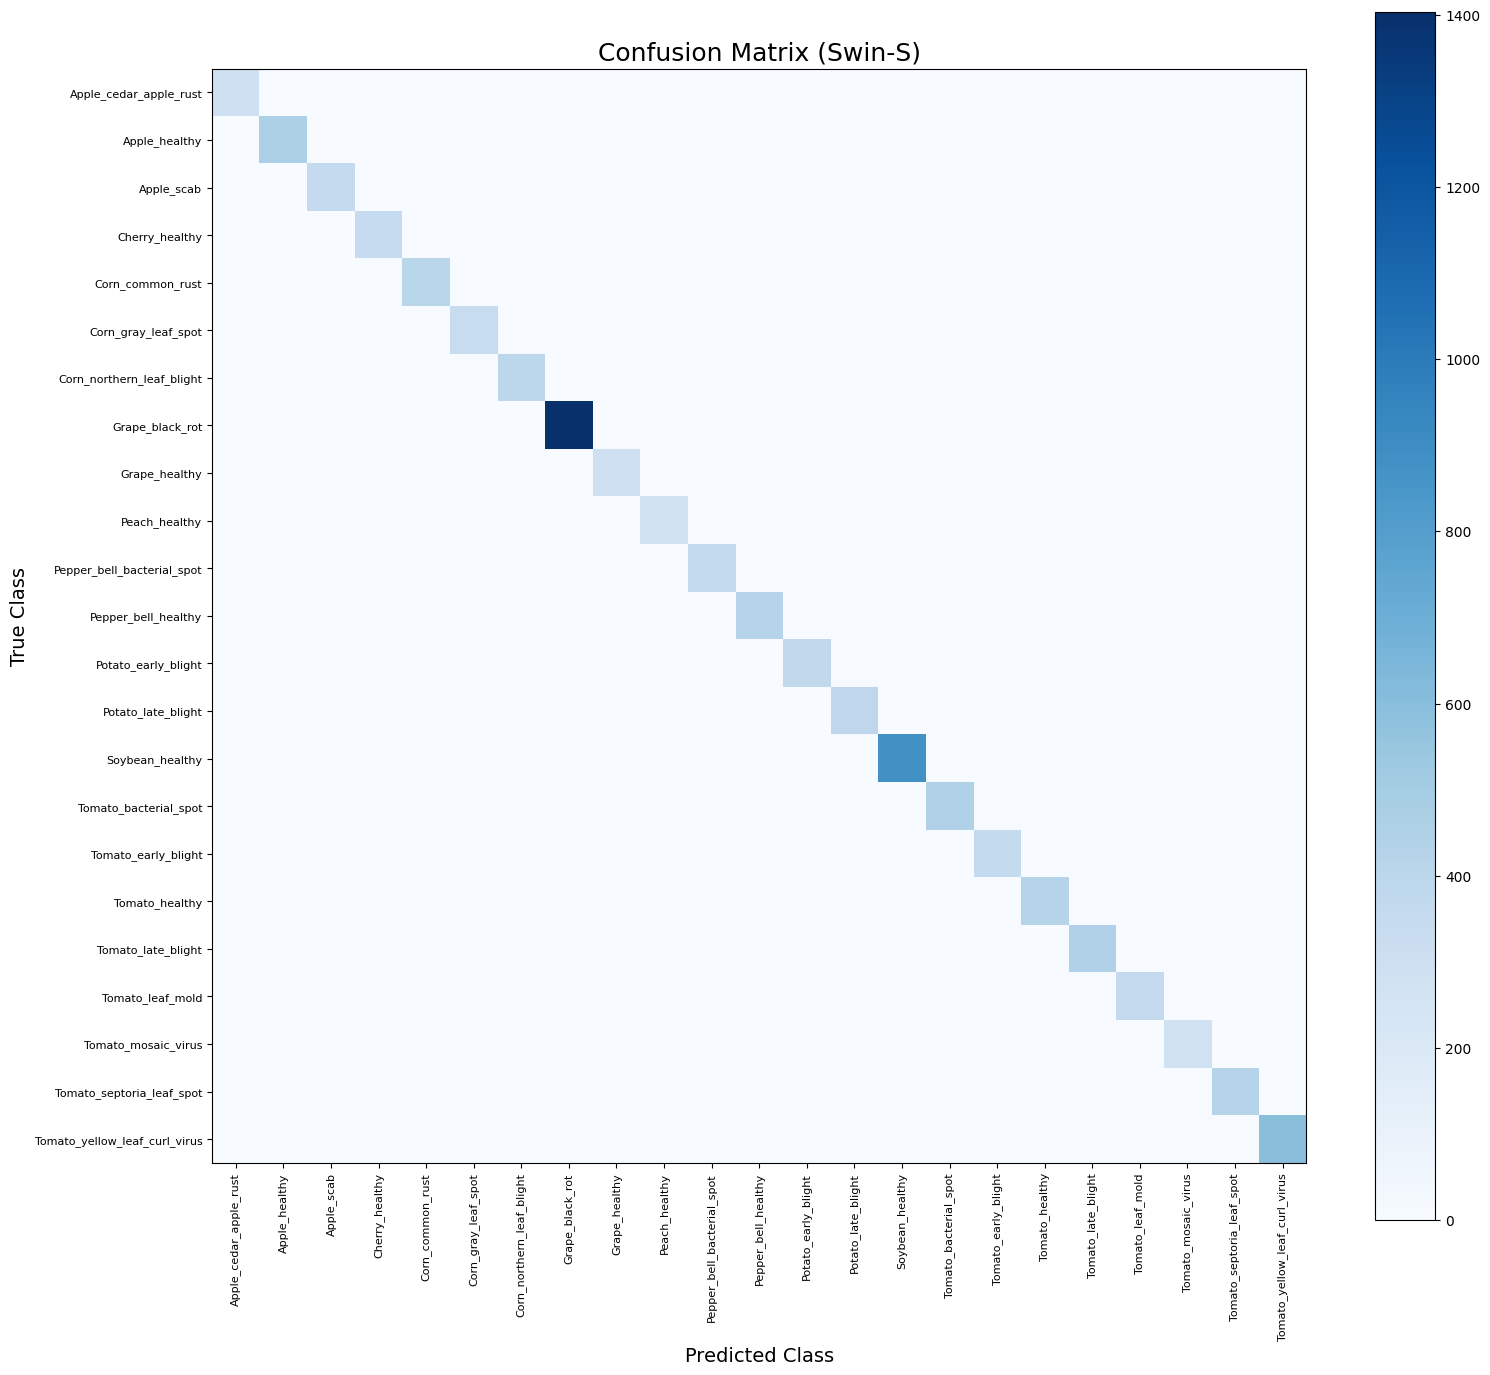

Confusion matrix saved to '/workspace/confusion_matrix.png'


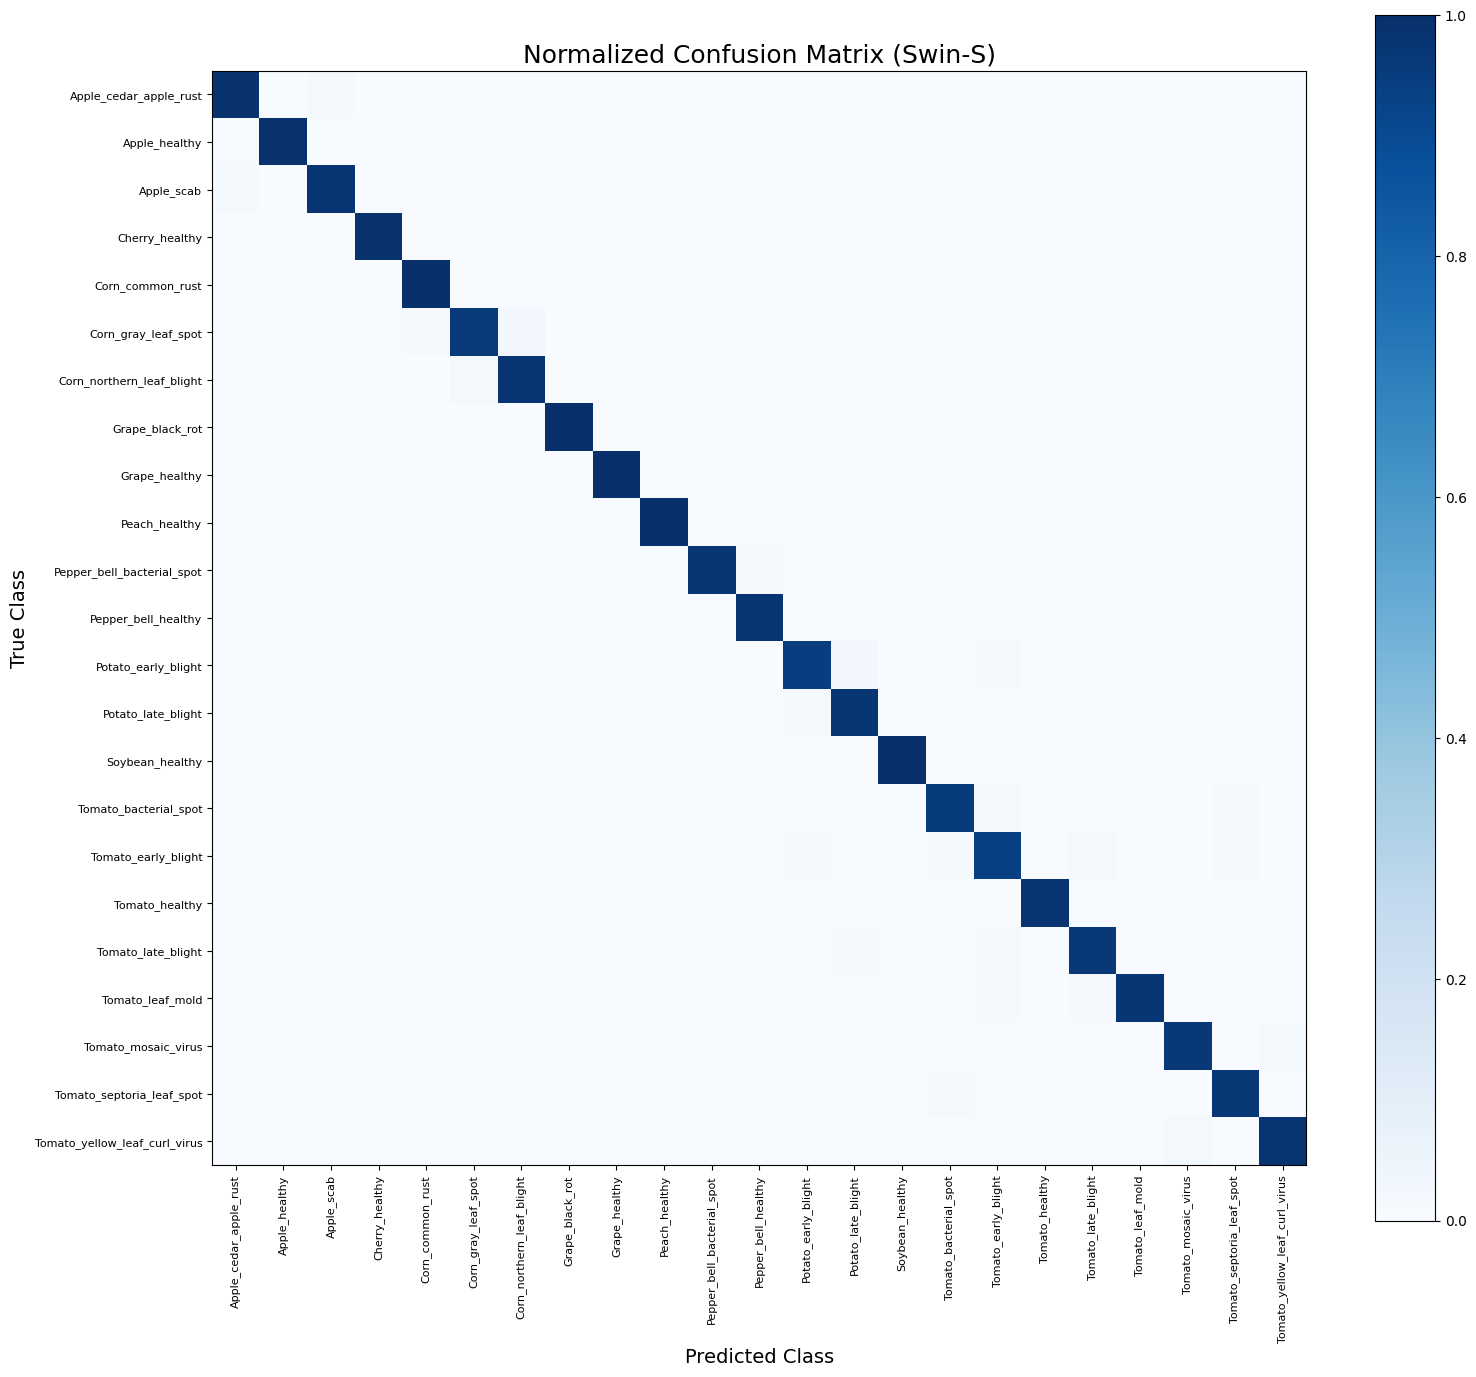

Normalized confusion matrix saved to '/workspace/confusion_matrix_normalized.png'

All done. Best model: '/workspace/best_swin_s_vast.pth'


In [29]:
# ============================================================
# PLOT AND SAVE CONFUSION MATRICES (Swin-S, 23 classes)
# ============================================================

# 1. Raw confusion matrix
plt.figure(figsize=(16, 14))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Swin-S)", fontsize=18)
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=90, fontsize=8)
plt.yticks(np.arange(len(class_names)), class_names, fontsize=8)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved to '/workspace/confusion_matrix.png'")

# 2. Normalized confusion matrix
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(16, 14))
plt.imshow(cm_normalized, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix (Swin-S)", fontsize=18)
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=90, fontsize=8)
plt.yticks(np.arange(len(class_names)), class_names, fontsize=8)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.tight_layout()
plt.savefig("/workspace/confusion_matrix_normalized.png", dpi=150)
plt.show()
print("Normalized confusion matrix saved to '/workspace/confusion_matrix_normalized.png'")

print("\nAll done. Best model: '/workspace/best_swin_s_vast.pth'")
